# 06 - Engagement analysis (game rounds)

**Goal:** test whether players in the two versions played different numbers of rounds,
using methods suited to extremely skewed data.

Revenue, playtime and session metrics in games are almost always skewed. Picking the right
test for skewed data - and showing how a single outlier can fool a mean - transfers directly
to those metrics.

In [1]:
import pandas as pd                                        # tables
import numpy as np                                         # maths
import matplotlib.pyplot as plt                            # charts
import seaborn as sns                                      # nicer charts
from scipy import stats                                    # t-test and Mann-Whitney test
from pathlib import Path                                   # file paths

sns.set_theme(style="whitegrid")                           # chart style
pd.set_option("display.max_columns", None)                 # never hide columns
pd.set_option("display.width", 200)                        # wide printing

In [2]:
ROOT = Path.cwd()                                          # folder the notebook runs in
if ROOT.name == "notebooks":                               # if inside notebooks/...
    ROOT = ROOT.parent                                     # ...go up to the project root
FIG_DIR = ROOT / "reports" / "figures"                     # charts folder
df = pd.read_csv(ROOT / "data" / "processed" / "cookie_cats_clean.csv")   # cleaned data with flags
control = df.loc[df["version"] == "gate_30", "sum_gamerounds"]           # control rounds
treat = df.loc[df["version"] == "gate_40", "sum_gamerounds"]             # treatment rounds
control_no_outlier = df.loc[(df["version"] == "gate_30") & (~df["is_implausible_rounds"]), "sum_gamerounds"]   # control without the impossible value
print(len(control), len(treat), len(control_no_outlier))   # expect 44700 45489 44699

44700 45489 44699


**Checkpoint:** `44700 45489 44699`. Exactly one row - the physically impossible 49,854-round
player - is set aside for the sensitivity check, and it is never removed from the retention analysis.

In [3]:
desc_rows = []                                             # list to collect one row per series
for label, series in [("gate_30 (all)", control), ("gate_30 (outlier removed)", control_no_outlier), ("gate_40 (all)", treat)]:   # loop over the three series
    desc_rows.append({                                     # store summary statistics
        "series": label,
        "players": series.size,
        "mean": series.mean(),
        "std": series.std(),
        "median": series.median(),
        "p75": series.quantile(0.75),
        "p90": series.quantile(0.90),
        "p99": series.quantile(0.99),
        "max": series.max(),
    })
print(pd.DataFrame(desc_rows).round(2))                    # show the table

                      series  players   mean     std  median   p75    p90     p99    max
0              gate_30 (all)    44700  52.46  256.72    17.0  50.0  135.0  493.00  49854
1  gate_30 (outlier removed)    44699  51.34  102.06    17.0  50.0  135.0  493.00   2961
2              gate_40 (all)    45489  51.30  103.29    16.0  52.0  134.0  492.12   2640


**Checkpoint**

| Series | Mean | Std | Median | p90 | p99 | Max |
|---|---|---|---|---|---|---|
| gate_30 (all) | 52.46 | 256.72 | 17 | 135 | 493.00 | 49,854 |
| gate_30 (outlier removed) | 51.34 | 102.06 | 17 | 135 | 493.00 | 2,961 |
| gate_40 (all) | 51.30 | 103.29 | 16 | 134 | 492.12 | 2,640 |

Removing one player out of 44,700 cuts the gate_30 standard deviation from 257 to 102, while
the median, p90 and p99 do not move at all. That is the difference between fragile and robust
statistics in one table.

In [4]:
t_all = stats.ttest_ind(treat, control, equal_var=False)                   # Welch t-test: does not assume equal variances
t_clean = stats.ttest_ind(treat, control_no_outlier, equal_var=False)      # same test without the impossible value
print("Mean diff (all):", round(treat.mean() - control.mean(), 3), "| p =", round(t_all.pvalue, 4))                            # about -1.16, p about 0.38
print("Mean diff (outlier removed):", round(treat.mean() - control_no_outlier.mean(), 3), "| p =", round(t_clean.pvalue, 4))   # about -0.04, p about 0.95

Mean diff (all): -1.157 | p = 0.3759
Mean diff (outlier removed): -0.043 | p = 0.9495


**Checkpoint:** mean difference -1.157 (p 0.3759) with the outlier, -0.043 (p 0.9495) without it.

Nearly the whole apparent difference in means came from one impossible value. Welch's t-test is
not wrong here - with 45,000 players per group the averages behave normally - the problem is that
the mean itself is a poor summary of this metric.

In [5]:
mw = stats.mannwhitneyu(treat, control, alternative="two-sided")           # rank-based test: do gate_40 players tend to play more or fewer rounds?
prob_superiority = mw.statistic / (treat.size * control.size)              # chance a random gate_40 player out-plays a random gate_30 player (ties count half)
rank_biserial = 2 * prob_superiority - 1                                   # effect size from -1 to +1 (0 = no difference)
print("Mann-Whitney p-value:", round(mw.pvalue, 4))                        # about 0.05 (borderline)
print("Probability of superiority:", round(prob_superiority, 4))           # about 0.496 (0.5 = no difference)
print("Rank-biserial correlation:", round(rank_biserial, 4))               # about -0.008 (tiny)

Mann-Whitney p-value: 0.0502
Probability of superiority: 0.4962
Rank-biserial correlation: -0.0075


**Checkpoint:** Mann-Whitney p about 0.0502, probability of superiority about 0.4962,
rank-biserial about -0.0075.

- The p-value sits right on the 0.05 line, so this is weak evidence that gate_40 players tend to
  play slightly fewer rounds.
- The effect size is tiny: a random gate_40 player out-plays a random gate_30 player 49.6% of the
  time, where 50% would mean no difference at all.
- Game rounds were never the decision metric, so a borderline result here does not move the
  recommendation.
- Mann-Whitney is often called a test of medians. That is only true when the two distributions
  have the same shape; in general it tests whether one group tends to produce larger values.

In [6]:
rng = np.random.default_rng(seed=11)                       # fixed seed for repeatable results
control_values = control.to_numpy()                        # convert to numpy for speed
treat_values = treat.to_numpy()                            # convert to numpy for speed
n_boot = 5000                                              # number of resamples
boot_median_diff = np.empty(n_boot)                        # storage array
for i in range(n_boot):                                    # one loop, one resample per iteration
    sample_c = rng.choice(control_values, size=control_values.size, replace=True)   # resample control
    sample_t = rng.choice(treat_values, size=treat_values.size, replace=True)       # resample treatment
    boot_median_diff[i] = np.median(sample_t) - np.median(sample_c)                 # median difference in this resample
print("Observed median diff:", np.median(treat_values) - np.median(control_values))   # 16 - 17 = -1
print("95% bootstrap CI:", np.percentile(boot_median_diff, [2.5, 97.5]))              # medians of whole numbers move in steps
print(pd.Series(boot_median_diff).value_counts(normalize=True).sort_index())          # how often each median difference appeared

Observed median diff: -1.0
95% bootstrap CI: [-1.  0.]
-1.0    0.9332
-0.5    0.0010
 0.0    0.0636
 1.0    0.0022
Name: proportion, dtype: float64


**Checkpoint:** observed median difference -1, bootstrap CI from -1 to 0, with -1 in about 93%
of resamples and 0 in about 6%.

Rounds are whole numbers, so a median can only move in steps of 1 (or 0.5 when a resample splits
evenly in the middle). That is why the bootstrap distribution is lumpy and the interval edges are
round numbers.

In [7]:
cap = df["sum_gamerounds"].quantile(0.99)                  # pooled 99th percentile across both groups
control_w = control.clip(upper=cap)                        # values above the cap are set equal to the cap
treat_w = treat.clip(upper=cap)                            # same cap for treatment
t_w = stats.ttest_ind(treat_w, control_w, equal_var=False) # Welch t-test on capped values
print("Cap value:", cap)                                   # about 493 rounds
print("Winsorized mean diff:", round(treat_w.mean() - control_w.mean(), 3), "| p =", round(t_w.pvalue, 4))   # robust mean comparison

Cap value: 493.0
Winsorized mean diff: -0.282 | p = 0.6152


**Checkpoint:** cap 493, winsorized mean difference -0.282, p 0.6152.

Capping the top 1% is a third way of asking the same question, and it agrees with the median and
rank-based answers: no practically meaningful difference in rounds played.

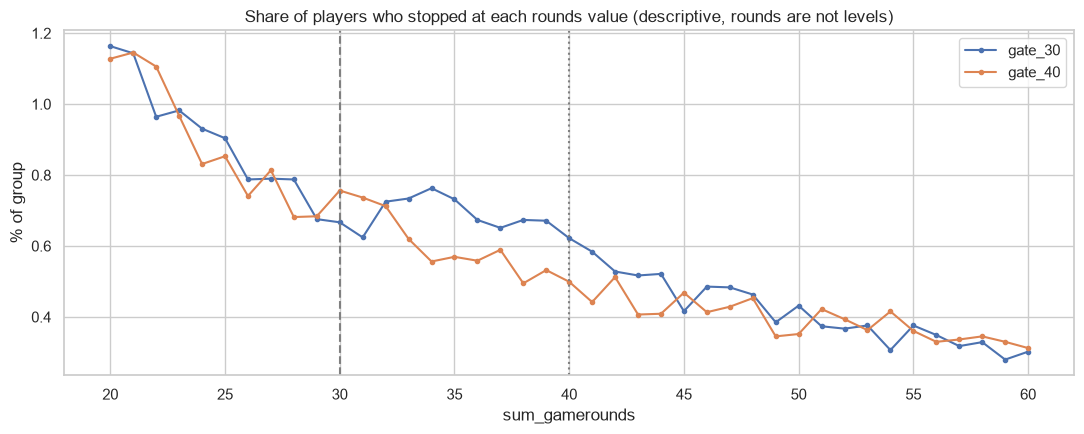

In [8]:
counts_by_value = pd.crosstab(df["sum_gamerounds"], df["version"])             # players at each exact rounds value per group
share_by_value = 100 * counts_by_value / counts_by_value.sum()                 # convert to % of each group
window = share_by_value.loc[20:60]                                             # focus on the zone around the two gates
fig, ax = plt.subplots(figsize=(11, 4.5))                                      # empty chart
ax.plot(window.index, window["gate_30"], marker="o", markersize=3, label="gate_30")   # control line
ax.plot(window.index, window["gate_40"], marker="o", markersize=3, label="gate_40")   # treatment line
ax.axvline(30, color="grey", linestyle="--")                                   # reference line at 30
ax.axvline(40, color="grey", linestyle=":")                                    # reference line at 40
ax.set_title("Share of players who stopped at each rounds value (descriptive, rounds are not levels)")   # title
ax.set_xlabel("sum_gamerounds")                                                # x label
ax.set_ylabel("% of group")                                                    # y label
ax.legend()                                                                    # legend
fig.tight_layout()                                                             # tidy
fig.savefig(FIG_DIR / "09_rounds_stop_points.png", dpi=150)                    # save
plt.show()                                                                     # display

This is the most interesting chart in the project. From roughly 33 to 44 rounds the gate_30 line
sits clearly above gate_40, which fits the idea that many gate_30 players stop shortly after
hitting the level-30 gate. It has to be presented carefully: rounds are not levels, because
players replay and fail levels, so the chart suggests a pattern rather than proving one.

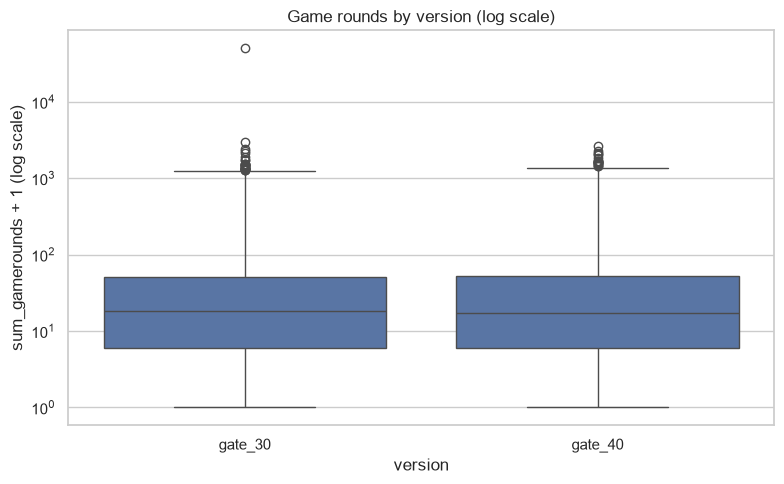

In [9]:
df["rounds_plus_1"] = df["sum_gamerounds"] + 1             # +1 so zeros work on a log scale
fig, ax = plt.subplots(figsize=(8, 5))                     # empty chart
sns.boxplot(data=df, x="version", y="rounds_plus_1", log_scale=True, ax=ax)   # boxplot per group
ax.set_title("Game rounds by version (log scale)")         # title
ax.set_ylabel("sum_gamerounds + 1 (log scale)")            # y label
fig.tight_layout()                                         # tidy
fig.savefig(FIG_DIR / "10_rounds_boxplot.png", dpi=150)    # save
plt.show()                                                 # display

## Engagement summary in plain English

There is no practically meaningful difference in rounds played between the versions. The means
looked different only because of one impossible value. The rank-based test is borderline with a
negligible effect size, and both the winsorized mean and the median agree. The one visible
pattern is *where* players stop: gate_30 players cluster just after 30 rounds.